# EE / CprE / CybE 3250: Machine Learning for Electrical, Computer, and Cybersecurity Engineering
## Lab-02: Linear Regression
> *[Note from your instructor: this the first lab that leverages the primary ML framework we are using semester, with the goal of learning how to perform linear regression on multiple ECpE-relevant datasets. Through this process you will gain experience with several important and fundamental concepts that will be used throughout the the course, including exploratory data analysis, linear models, backpropagation, training vs. validation, and under/over fitting. Work with your partner over the next two weeks to follow a step-by-step example, adapt this from-scratch example on a separate dataset, and utilize higher-level framework functionality to develop your own implementation of linear regression. Collaborative learning is encouraged, as is the use of generative AI to assist with debugging coding challenges, as long as the answers to all conceptual questions are intellectually your own. Team learning is always encouraged, as long as the end product is intellectually your own. You will be assessed based on a combination of lab preparation (PreLab), answers to programming and conceptual questions (Lab), and demonstration of understanding (PostLab).]*

**Names:** 

**Group Name:**



### 0. Prelab
Please read through this entire document and answer the questions at the end under the “Prelab Questions” section header. These are due and will be checked at the beginning of the lab – please post if you have any questions.


In [2]:
# Initial setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from d2l import torch as d2l

### 1. Initial Dataset and Exploratory Data Analysis (EDA)
For our first foray into Linear Regression, we will start with the Building Energy Efficiency dataset provided by the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/242/energy+efficiency). This file is provided for you locally as `data\building_energy_efficiency_data.csv`, and we can use pandas as in Lab-01 for opening the dataset and performing an initial exploration.


In [3]:
# Use pandas to read the CSV file, info() to display data information, head() to display the header and first few rows, and describe() to provide summary statistics. 
df1 = pd.read_csv('data/building_energy_efficiency_data.csv');
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [4]:
df1.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
df1.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


This dataset comes from a 2012 study that looked at the `Heating_Load` and `Cooling_Load` requirements of buildings (in other words, the relative energy efficiency of buildings measured in kWh/m^2) as a function of building parameters. The dataset includes 768 distinct building shapes. Several of the encoded features are relatively self-explanatory (e.g. `Roof_Area`, `Overall_Height`), whereas others are less clear:
* `Relative_Compactness` is the ratio of the total volume of the building to the volume of an equivalent perfect rectangular prism (the product of the overall width, length, and height of the building).
* `Orientation` is a category parameter representing the building orientation, with `2` representing North, `3` East, etc. 
* `Glazing_Area` and `Glazing_Area_Distribution` refer to the surface area of glass windows or doors (also referred to as [Glazing](https://en.wikipedia.org/wiki/Glazing_(window))), as a ratio of the floor area and as a categorical distribution. 

Our goal is to be able to predict `Heating_Load` and/or `Cooling_Load` given the other 8 features, but before blindly jumping inton any regression task, it's important to first better understand our data. 

As an initial pass, let's check if there is any missing data, which we would need to discard or fill in with representative values, or duplicated rows, which we would have to decide how to handle depending on context. 

In [6]:
# .isna() returns a Boolean if the data is missing, which we then sum up and convert to a Label: Value dict
print(f"Missing data values: {df1.isna().sum().to_dict()}")

# .duplicated() returns a Boolean series for any duplicated rows
print(f"Number of duplicated rows: {df1.duplicated().sum()}")

Missing data values: {'Relative_Compactness': 0, 'Surface_Area': 0, 'Wall_Area': 0, 'Roof_Area': 0, 'Overall_Height': 0, 'Orientation': 0, 'Glazing_Area': 0, 'Glazing_Area_Distribution': 0, 'Heating_Load': 0, 'Cooling_Load': 0}
Number of duplicated rows: 0


We can use other built-in features of pandas to visualize our features' in terms of histrograms, box plots, and correlations. Here we display histograms, box plots, a scatter matrix (where the diagonal displays a density estimation for each feature), and a correlation heatmap. 

Lets first look at the feature distribution of our data using histograms. We can filter out the data to only include numeric features by using the `select__dtypes()` function. This isn't strictly necessary for this Building Energy Efficiency dataset, since all of our features are numeric anyways, but it is a good practice to follow.

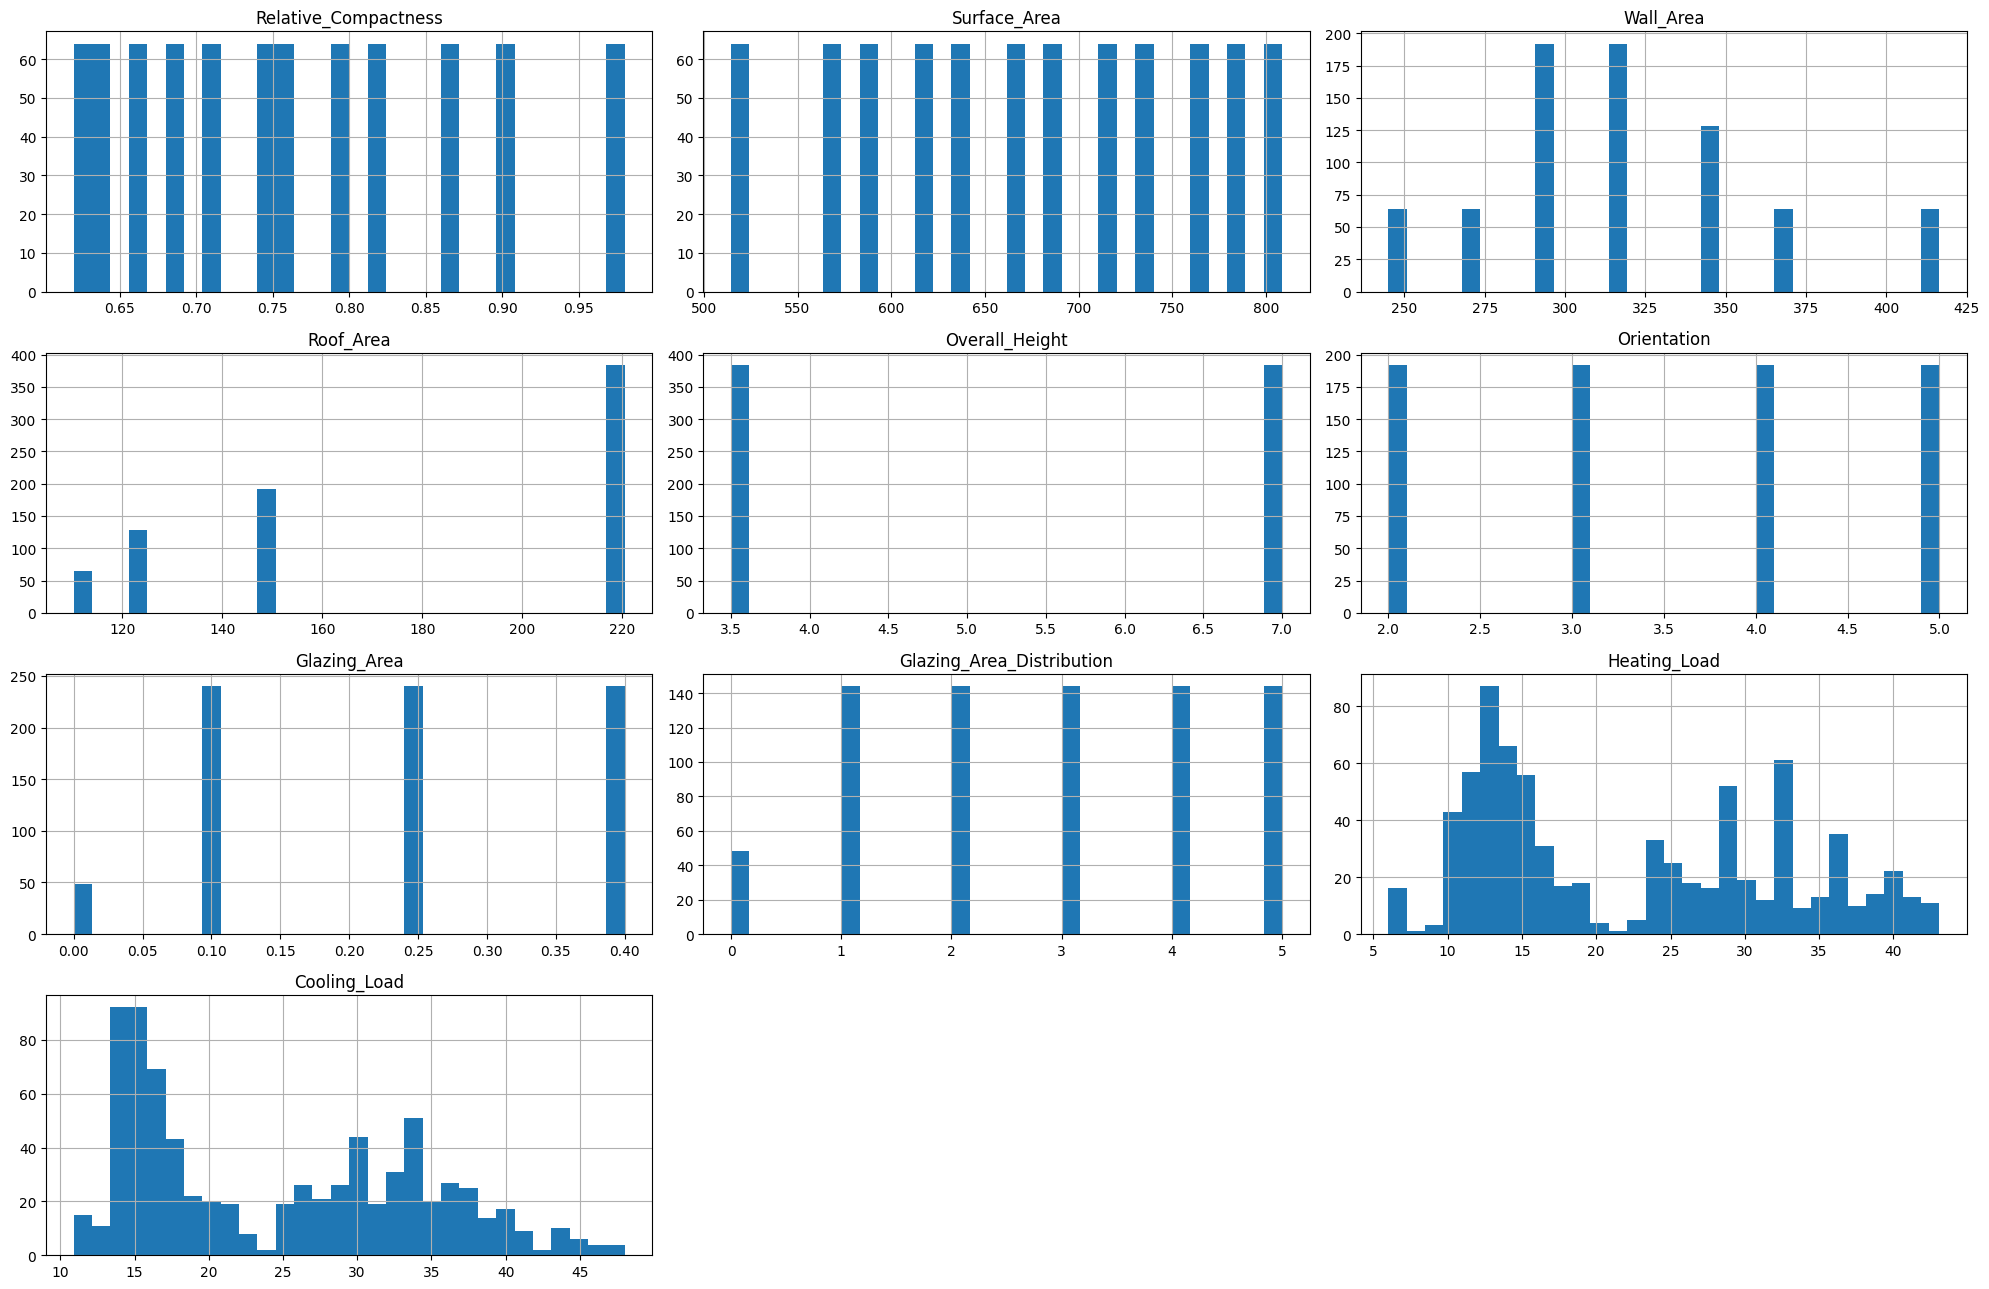

In [7]:
# Although not necessary for this dataset, we really only want columns with numeric data for analysis. 
# Later, we can use one-hot encoding or other techniques to convert categorical data to numeric data.
numeric_cols = df1.select_dtypes(include=[np.number]).columns

# .hist() displays a histogram of the dataframe
_ = df1[numeric_cols].hist(figsize=(20,13),bins=30)

plt.tight_layout()

- **Q1.1:** Notice above that some features are continuous, whereas some are discrete (limited to a few values). Pay attention to our target features, `Heating_Load` and `Cooling_Load`. Are these variables unimodal (one major peak) or bimodal (two major peaks)? What might this tell us about the building types in the dataset?

- **A1.1:** These look bimodal which seems to tell us that there are two broad categories of buildings which i would assume would be industrial buildings and apartments probably.

Now, we display the box plots of our different features, giving us insight into the range and characteristics (mean and interquartile range) of the variables.

<Axes: >

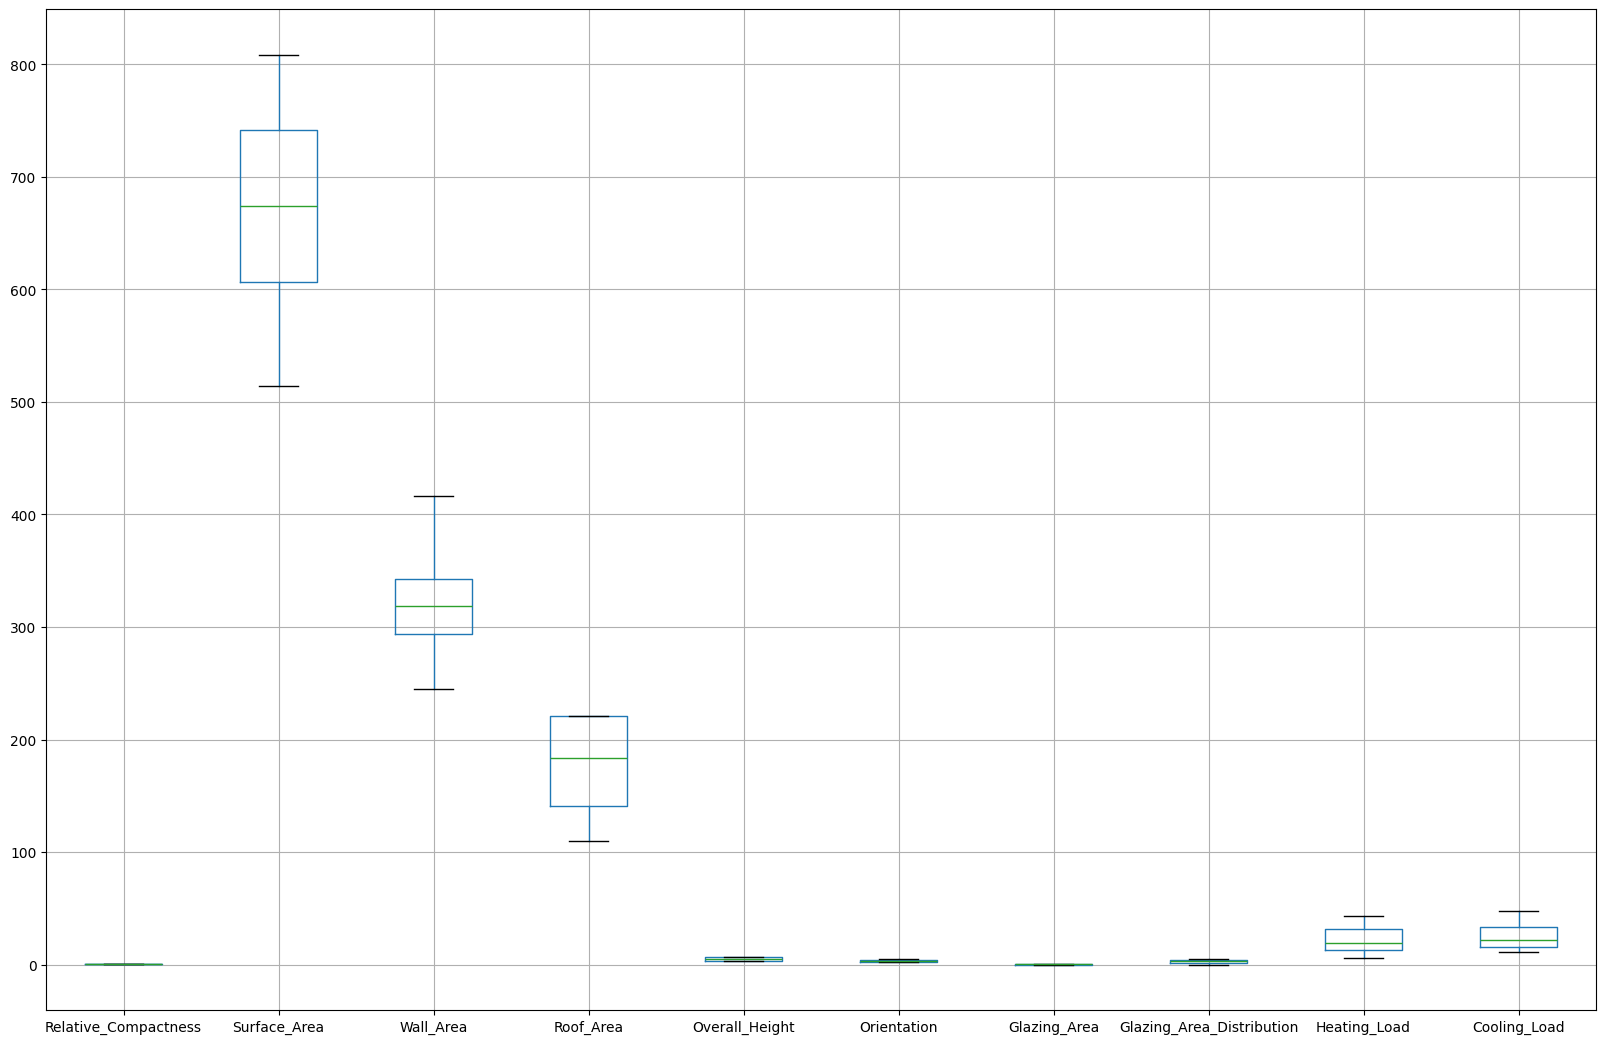

In [8]:
# .boxplot() displays a box plot of the data
df1[numeric_cols].boxplot(figsize=(20,13))

- **Q1.2:** Note above the significant differences in scale between the values of `Surface_Area` and `Relative_Compactness`. Why would feeding these features directly into a machine learning model be problematic? What type of preprocessing step could we introduce to help introduce this issue?

- **A1.2:** ### Come Back to this later

Now, we look at a scatter matrix (a matrix of scatter plots) of our data, allowing us to see the relationships between features.

<Figure size 4000x2000 with 0 Axes>

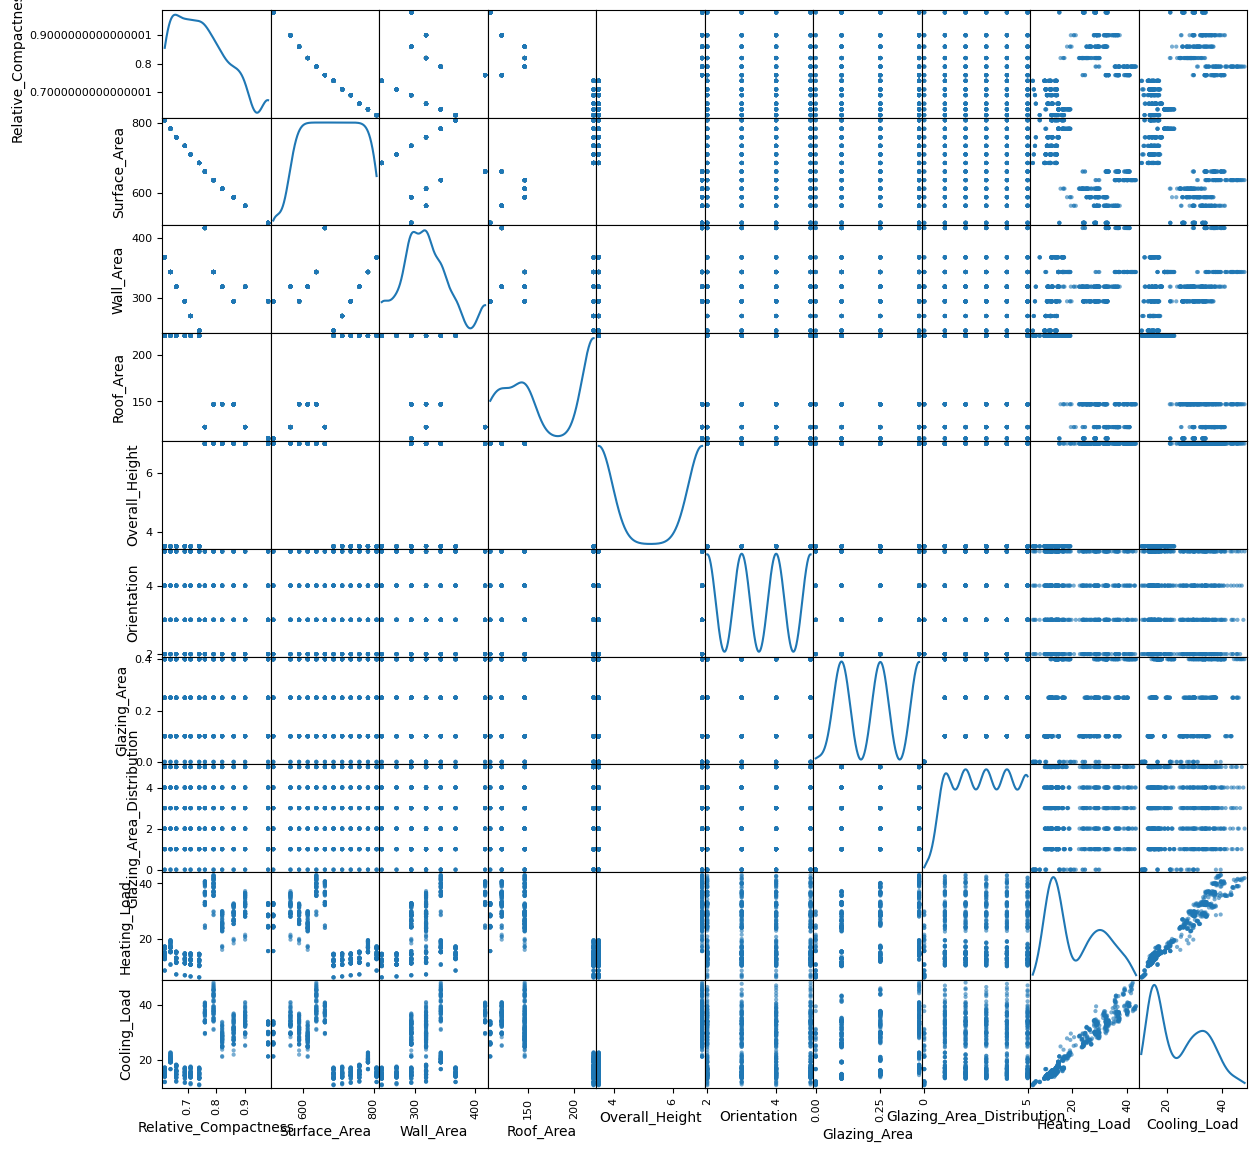

In [9]:

# Importing the function directly isn't necessary, we could otherwise just call pd.plotting.scatter_matrix()
from pandas.plotting import scatter_matrix
plt.figure(figsize=(40, 20))
_ = scatter_matrix(df1[numeric_cols], figsize=(14, 14), diagonal='kde', alpha=0.6)


Finally, we can generate and plot a correlation matrix, which computes the pearson correlation coefficient for every pair of features in the dataset. The closer the value is to 1.0, the more positively linearly correlated the features are, and the closer to -1.0, the more negatively linearly correlated they are. Using the `.corr()` function calculates the Pearson correlation coefficients across all variable pairs; mathematically, this looks like:

$$ \rho(x,y) = \frac{ \left({\mathbf{x}}-\bar{x}\right)^{\top} \left({\mathbf{y}}-\bar{y}\right) }{ \left\|{\mathbf{x}}-\bar{x}\right\|_2 \left\|{\mathbf{y}}-\bar{y}\right\|_2 } $$

Here, $\bar{x}$ and $\bar{y}$ are the means of the two vectors. While this function looks a bit complicated, it is essentially just determining how two vectors, ${\mathbf{x}}$ and ${\mathbf{y}}$ in this example, move relative to each other. Along the main diagonal you see all 1.0, since the vector is getting compared to itself, and is therefore perfectly correlated. 

The correlation matrix is plotted as a heatmap, which provides a dynamic color range for a quick visual analysis. 

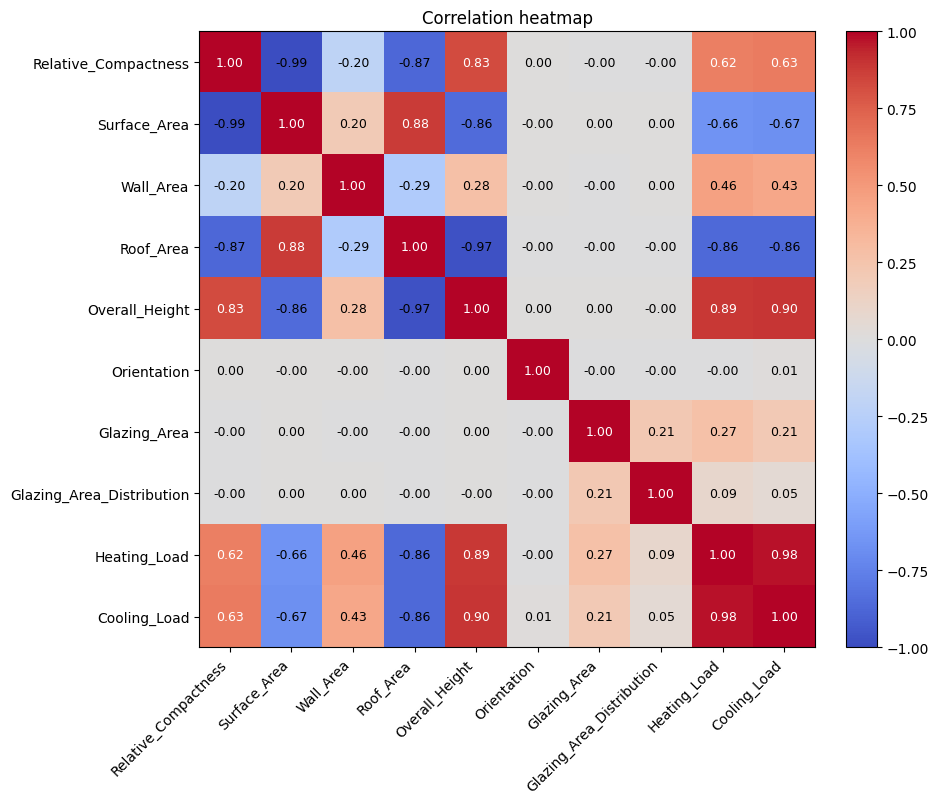

In [10]:
# .corr() computes the Pearson correlation matrix
corr = df1[numeric_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(corr.index)), labels=corr.index)
plt.title("Correlation heatmap")

# Plot the actual correlation values as data labels on the heatmap
vals = corr.values
nrows, ncols = vals.shape
for i in range(nrows):
    for j in range(ncols):
        v = vals[i, j]
        # Choose text color for contrast: light text on strong positive, dark otherwise
        text_color = "white" if v > 0.5 else "black"
        plt.text(j, i, f"{v:.2f}", ha="center", va="center", color=text_color, fontsize=9)

- **Q1.3:** Between the scatter and correlation matrices, you can clearly see how different features are related to one another. What input features do you expect to have the largest impact (with resulting weights and biases) on `Heating_Load` and `Cooling_Load`?  Which single feature seems to have the strongest relationship with heating and cooling loads?

- **A1.3:**  Overall heigh not considering the opposite load effect like the cooling load on heating and heating load on cooling.

- **Q1.4)\:** In your own words, summarize what have you learned about this dataset from this initial exploration and visualization? In what ways is this dataset representative of buildings and energy efficiency in general, and in what ways is it not representative? 

- **A1.4)\:** It is represantative of buildings in the fact that nominally we would expect that taller buildings consume more energy because they require more space to send heat or cold air around which increases the load on the HVAC   

So far, so good (but please note that most real-world data will not be as clean as this). Let's start to manipulate our data so that it is more amenable to performing linear regression. We grab the individual input features as matrix $\mathbf{{X}}$ and output (`Heating_Load` for now) as $\mathbf{{y}}$.  Then, we create a scaled copy of our inputs `X_raw` by calculating the means and standard deviations of the column-wise features and applying the scaling mechanism 

$$\hat{{\mathbf{X}}} = \frac{{\mathbf{X}} - \boldsymbol{\mu}}{\boldsymbol{\sigma}}$$

Here, $\boldsymbol{\mu}$ are the means of $\mathbf{X}$ and $\boldsymbol{\sigma}$ are the standard deviations of $\mathbf{{X}}$.

In [11]:
X_raw = df1[numeric_cols].drop(['Heating_Load','Cooling_Load'], axis=1)
Y = df1[['Heating_Load']]

means = X_raw.mean()                    # column means
stds = X_raw.std(ddof=0)                # population std (ddof=0 like StandardScaler)
safe_stds = stds.replace(0, 1.0)    # Protect against zero variance to avoid divide-by-zero

print(f"Means of raw features: {means.to_dict()}")
print(f"Standard deviations of raw features: {safe_stds.to_dict()}")

# Copy the raw data to avoid modifying it directly
X_scaled = X_raw.copy()
X_scaled = (X_scaled - means) / safe_stds


Means of raw features: {'Relative_Compactness': 0.7641666666666667, 'Surface_Area': 671.7083333333334, 'Wall_Area': 318.5, 'Roof_Area': 176.60416666666666, 'Overall_Height': 5.25, 'Orientation': 3.5, 'Glazing_Area': 0.234375, 'Glazing_Area_Distribution': 2.8125}
Standard deviations of raw features: {'Relative_Compactness': 0.1057085878987869, 'Surface_Area': 88.02874964401623, 'Wall_Area': 43.598069529127855, 'Roof_Area': 45.136535729261375, 'Overall_Height': 1.75, 'Orientation': 1.118033988749895, 'Glazing_Area': 0.13313380252587997, 'Glazing_Area_Distribution': 1.5499495959546556}


- **Q1.5)\:** Conceptually, how have we transformed the inputs features (e.g. $\mathbf{X}$)? Why is this feature scaling important for gradient descent in linear regression? What might happen if features have very different scales? Answer briefly below, and use the subsequent code block to explore how two of the features in `X_scaled` are visually different than its equivalent feature in `X_raw`. To do this, chose two features from the dataframe and create a `matplotlib` figure with subplots for each, plotting both the scaled and raw data for each feature to compare.

- **A1.5)\:** If features have very different scales they might cause the gradient/gradient descent to blow up

768
768


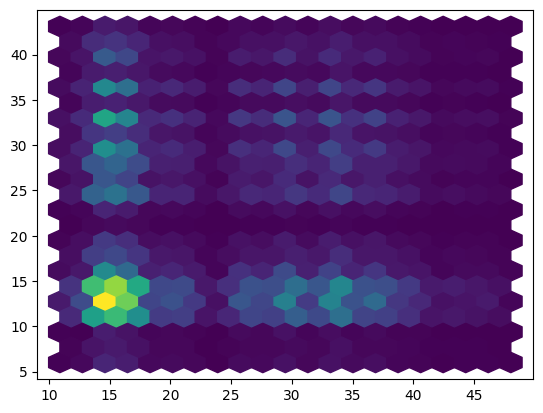

In [12]:
# Code for Q1.2 here. Visually compare the distributions of two of the raw and scaled features
# YOUR CODE STARTS HERE
import matplotlib.pyplot as plt


X_data_1 = df1["Cooling_Load"]

X_data_2 = df1["Cooling_Load"]
X_data_2_std = X_data_2.std(ddof=0)
X_data_2 = (X_data_2 - X_data_2.mean()) / X_data_2_std

print(X_data_1.size)
#print(X_data_2.size)
print(Y.size)
fig, ax = plt.subplots()

ax.hexbin(X_data_1,Y,gridsize=20)

plt.show()
#ax.plot(X_data_2,Y)




# YOUR CODE ENDS HERE


### 2. Working with the D2L Framework
Similar to what we have been doing in class, we will be utilizing the [D2L](https://d2l.ai/) framework, as it allows for a more student-centric approach than solely using pytorch, JAX, or others. One consequence of this choice is that we will always need to setup appropriate D2L classes before we can perform any training in earnest. We will start by creating a class that handles the loading and training / validation split of our Energy Efficiency dataset:

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
class BuildingEnergyEfficiencyData(d2l.DataModule):  #@save
    """Building Energy Efficiency data for linear regression."""
    def __init__(self, building_energy_df='data/building_energy_efficiency_data.csv', train_val_split=0.8, batch_size=32):
        super().__init__()

        # Process energy_df similar as in part 1 when it was called df1
        # The resulting self.X and self.y need to be torch.tensors, so be sure to convert from pandas DataFrame to numpy array to torch tensor
        # .values gets the underlying numpy array from the DataFrame, and .to(torch.float32) converts to float32 tensor
        # example: tensor_vals = torch.tensor(dataframe[column_name].values).to(torch.float32)
        
    # YOUR CODE STARTS HERE

        # Use this 
        df = pd.read_csv(building_energy_df);
        #later take a look at .sample function pandas
        df_train = df.copy()

        df_validate = df.copy()
        df_train = df.drop(["Heating_Load"], axis =1)
        df_train = df.drop(["Cooling_Load"], axis =1)
    
        df_train.info()
        # df_validate.info()

        self.X = torch.tensor(df_train[:].values).to(torch.float32)
        self.X = (self.X - self.X.mean())/self.X.std()

        self.y = torch.tensor(df_validate["Heating_Load"].values).to(torch.float32)
        self.y = (self.y - self.y.mean())/self.y.std()

        self.num_train = len(df_train)
        
       


        # print(len(self.data_loaded_x))
        # print(len(self.data_loaded_y))



    # YOUR CODE ENDS HERE

@d2l.add_to_class(BuildingEnergyEfficiencyData)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)


load = BuildingEnergyEfficiencyData()





<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


For each new dataset we work with, we will need to define a corresponding class, and work with the following functions:
* `__init__()`, which initializes our data handler based on input hyperparameters.
* `save_hyperparameters()`, which saves all the function arguments to `__init__()` into class attributes. This is already implemented.
* `get_dataloader()`, which returns the next batch of either training or validation data. This is already implemented and is shown above. 
* `train_dataloader()`, a helper function that calls `get_dataloader()` with `train==true`.
* `val_dataloader()`, a helper function that calls `get_dataloader()` with `train==false`.

You can define these functions directly in the `class` block, or use the `@d2l.add_to_class()` helper to update your data class. Note that while the D2L framework is entirely open-source (and available on your lab computers), we will try to avoid having to dive deeper into the implementation except when absolutely necessary. But feel free to take a look on [Github](https://github.com/smolix/d2l-neu/blob/main/d2l/torch.py) - there's no magic there!

- **Q2.1)\:** The implementation of `__init__()` above is incomplete, as we have to provide appropriate values for `num_train`, `num_val`, and set `X` and `y` accordingly. Implement this block and in the space below, in your own words, provide an explanation of what each line you added is doing and why. Note that this step should primarily be reusing code from Part 1 of this lab - the `__init()__` takes in the pandas dataframe from our CSV file and is performing the same steps! Note the comment above that we need to be working with pytorch [tensors](https://docs.pytorch.org/docs/stable/tensors.html) as opposed to our pandas and numpy objects we've been using so far this lab.  

- **A2.1)\:** 

Confirm that your implementation is functioning correctly by creating an object of type `BuildingEnergyEfficiencyData`, loading a batch of data, and visualizing that batch. Starting code for this part is provided below. 
<!--A small Python quirk of the D2L implementation of `get_dataloader()` is that it uses `yield` which turns a function into a [function generator](https://www.w3schools.com/python/ref_keyword_yield.asp), and does exactly what we want, in returning the next batch of features and labels each time `get_dataloader()` is called.-->

- **Q2.2)\:** Plot a histogram of any of the input features returned after calling `.train_dataloader()`. Compare to the previously plotted histograms of the corresponding feature from the initial exploratory data analysis. The graphs should look similar but not identical. Explain two key differences between the histograms and their cause. 

- **A2.2)\:** 


In [14]:
building_energy_df = pd.read_csv('data/building_energy_efficiency_data.csv')
BuildingEnergy = BuildingEnergyEfficiencyData(building_energy_df)    # This will otherwise use the default parameters for the init() of EnergyEfficiencyData()

# Use iter() to turn the dataloader generator into an iterator, then use next() to get the next batch
X, y = next(iter(BuildingEnergy.train_dataloader()))

# Plot this histogram of the first feature in the first training batch

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


768
768


AttributeError: 'BuildingEnergyEfficiencyData' object has no attribute 'num_train'

### 3. Linear Regression from Scratch
Now that we have a way of loading training and validation data, we can begin to build a model for regression. In linear algebra notation, assuming the relationship between features $\mathbf{x}$ and target $y$ is approximately linear, our goal is to generate a prediction $\hat{y}$ (in general the "hat" symbol denotes an estimate) as a weighted sum of the features:

$$\hat{y} = w_1  x_1 + \cdots + w_d  x_d + b.$$

Here, the $w_{j}$ values are called *weights*, and $b$ is called a *bias* (or *offset* or *intercept*). The weights determine the influence of each feature on our prediction. The bias determines the value of the estimate when all features are zero. Collecting all the features into a vector $\mathbf{x}$ and all weights into a vector $\mathbf{w}$, our model can be then expressed simply as the dot product between $\mathbf{w}$ and $\mathbf{x}$:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b.$$

Given our building energy dataset, our goal is to determine what values of the weights $\mathbf{w}$ and the bias $b$ allow for our model's predictions of the values $\hat{y}$ match the actual values $y$ as closely as possible, where $y$ is `Heating_Load`. This notation  corresponds to the features of a single sample. When considering multiple samples (or an entire dataset) of length $n$, we then refer to the input matrix $\mathbf{X}$ which contains one row for every sample and one column for every feature. This allows us to represent the predictions for all samples ($\hat{\mathbf{y}}$) as a matrix-vector product:

$${\hat{\mathbf{y}}} = \mathbf{X} \mathbf{w} + b.$$

Using the D2L framework, we declare a model object that defines and initializes values for $\mathbf{w}$ and $b$. For now, we initialize our weights $\mathbf{w}$ by generating random numbers from a normal distribution with mean of 0
and a standard deviation of `sigma=0.01`. The bias $b$ we initialize to 0. 

In [ ]:
class LinearRegression_v1(d2l.Module):  #@save
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr=0.03, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

Although not complete, let's test out that our model has been initialized with weights and biases. Update the code block below to also display the shape of our model's $\mathbf{w}$ and ${b}$, and to display the initialized values. 

- **Q3.1)\:** What are the dimensions for $\mathbf{w}$ (`self.w`) and $b$ (`self.b`)? Why did we need to consider the number of input features when initializing this model?

- **A3.1)\:** 


- **Q3.2)\:** If we wanted this model to predict both `Heating_Load` *and* `Cooling_Load`, how would our dataloader change, and what would need to change in our model implementation above? Be specific. 

- **A3.2)\:** 

In [ ]:
# Grab a batch to determine the number of input features
X, y = next(iter(BuildingEnergy.train_dataloader()))
num_inputs = X.shape[1]

BuildingModel = LinearRegression_v1(num_inputs, lr=0.03)

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


Our model doesn't actually **do** anything yet. Using the same mathematical notation as before, for our linear model, we simply take the matrix-vector product of the input features of the input features $\mathbf{X}$ and the model weights $\mathbf{w}$, and add the offset $b$ to each sample. Note that since $b$ is a scalar (when we have just 1 output feature), the addition is calculated via [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) the scalar to the resulting $\mathbf{X} \mathbf{w}$ vector.

For a linear model, these calculations are referred to as the *forward* pass and in our framework is implemented as class method `foward()`, that takes in a batch of values `X` and uses the PyTorch function `torch.matmul()` to perform this matrix multiplication:

In [ ]:
@d2l.add_to_class(LinearRegression_v1)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

Let's manually confirm that our forward pass does what we expect it to do:

In [ ]:
print(X.shape, y.shape, BuildingModel.type)   # using the initially loaded data from before

# Calculate y_hat using the .forward() method and manually, then compare to ensure they are the same
y_hat1 = BuildingModel.forward(X) 
y_hat2 = X @ BuildingModel.w + BuildingModel.b
print((y_hat1-y_hat2).sum())

- **Q3.3)\:** Does our `BuildingModel` make a good prediction of $\hat{y}$ (the `Heating_Load`)? Why or why not? Explain your reasoning, and use the following code block to visualize your answer. One approach would be to visualize your answer by plotting the residuals of `y_hat` compared to `y`. Note that `matplotlib` does not plot tensors directly - convert any values to `numpy` arrays first. 

- **A3.3)\:** 

In [ ]:
# Determine the accuracy of the model's initial prediction

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


While we can visualize how accurate our initial predictions are, to actually train and fit our model to the data requires that we decide on some quantifiable measure of accuracy (or lack of accuracy). This is generally referred to as a *loss function*, where the goal of the function is to calculate the distance between the actual (${{\mathbf{y}}}$) and the predicted (${\hat{\mathbf{y}}}$) values.

For regression tasks, a common loss function is the *squared error*, which as the name suggests, is the square of the distance between the prediction and the actual value. For a sample $i$, prediction $\hat{y}^{(i)}$, and the corresponding true label is $y^{(i)}$,
the squared error is given by:

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2} \left(\hat{y}^{(i)} - y^{(i)}\right)^2.$$

The constant $\frac{1}{2}$ is added to simplify the calculations required when we eventually take the derivative of this loss function, as the power rule will cancel it out. 

This equation calculates the loss for a single sample $i$, and for our entire dataset of $n$ samples, we can average the losses on the training data:

$$L(\mathbf{w}, b) =\frac{1}{n}\sum_{i=1}^n l^{(i)}(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

This leads to a more formal definition for our goal of training a linear model: we seek parameters ($\mathbf{w}^*, b^*$)
that minimize the total loss across all training examples:

$$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b}\  L(\mathbf{w}, b).$$



Going back to our D2L framework, our next task is to implement this function, called `loss()`, which takes in the calculated / predicted values (${\hat{\mathbf{y}}}$, or `y_hat`) and the known values (${{\mathbf{y}}}$, or `y`), and returns $L$.

- **Q3.4)\:** Implement `loss()` below, and briefly explain your code for this part. 

- **A3.4)\:** 


In [ ]:
@d2l.add_to_class(LinearRegression_v1)  #@save
def loss(self, y_hat, y):
# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


The final consideration before we can begin training is the utilization of a well-known algorithm for optimization, which is used in nearly every deep learning model. The goal of this approach, referred to generally as *gradient descent*, is to iteratively reduce prediction error by updating the parameters of our model in the direction that incrementally lowers the loss function. 

While there are many variants of gradient descent, they all involve taking the derivative of the loss function with respect to the model parameters, where at one extreme we take this derivative after processing all inputs, or at an another extreme taking this derivative after processing a single input at a time (referred to as *stochastic gradient descent* (SGD)). The intermediate strategy, and the one that we will explore, is to take a *minibatch* of inputs (often a power of $2$ between 32 and 256), resulting in an approach referred to as *minibatch stochastic gradient descent*. 

In its most basic form, in each iteration $t$, we first randomly sample a minibatch $\mathcal{B}_t$ consisting of a fixed number $|\mathcal{B}|$ (`batch_size` in our implementation) of training examples. We then compute the derivative (gradient) of the average loss on the minibatch with respect to the model parameters. Finally, we multiply the gradient by a predetermined small positive value $\eta$, called the *learning rate* (`lr` in our implementation), and subtract the resulting term from the current parameter values. We can express the update as follows:

$$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b).$$

While this seems quite ambitious to implement, handling gradients is where PyTorch really shines. For our `tensor` objects, calculating the gradient of the loss function can be performed in a single method (`.backward()`), after which the appropriate gradient values are stored in the corresponding `.grad` attributes of our model parameters. The D2L framework handles this by defining an `SGD` class with a `step()` function to update the parameters, which we can then register as being the optimizer we will use during training:


In [ ]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

@d2l.add_to_class(LinearRegression_v1)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

Notice above that we also define the function `zero_grad()`; during training, we want the optimizer to use autograd to calculate the gradient of our `loss` function in order to update our parameters. However, as we saw in Lect-02, these gradient values continue to accumulate, and so after each minibatch, we will want to reset them.

Now that we have all the parts in place (data, model, loss function, and optimizer), we are finally ready to **implement the main training loop**. While the code for this part is provided as part of the D2L library, it is important that you attempt to understand it fully. In future assignments, you will be expected to develop something similar. 

Conceptually, in each *epoch*, we iterate through the entire training set, batch by batch. In each *iteration*, we load the next batch of training samples, compute the model's loss, calculate the gradients with respect to each parameter, and update the model parameters. 

Not all of the implementation details are provided here - and this block can be a little opaque to read as the code makes use of several methods that are not shown here. You might find it helpful to review the D2L source code that is available in your local install (or on [Github](https://github.com/smolix/d2l-neu/blob/main/d2l/torch.py)). Other functions (e.g. `model.train()`) are directly from PyTorch. 


- **Q3.5)\:** Review the code block below, and describe in your own words, where the following steps happen:

    a) Where the batch of training data is loaded

    b) Where the forward pass of the model is calculated

    c) Where the loss is calculated

    d) Where the gradients are calculated

    e) Where the model parameters are updated

- **A3.5)\:** 


In [ ]:
@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

### 4. Training, Validation, and Inference
We are **finally** ready to train our first model! Let's set the learning rate `lr=0.03`, and the number of epochs `max_epochs=10`. Note that in general, both the number of epochs and the learning rate are hyperparameters and can be further optimized. 

Run the following code, and **confirm your results with your TA before proceeding**. 

In [ ]:
BuildingEnergy = BuildingEnergyEfficiencyData(building_energy_df, train_val_split=0.8, batch_size=32)  
X, y = next(iter(BuildingEnergy.train_dataloader()))
num_features = X.shape[1]

BuildingModel = LinearRegression_v1(num_features, lr=0.03)

BuildingModelTrainer = d2l.Trainer(max_epochs=10)
BuildingModelTrainer.fit(BuildingModel, BuildingEnergy)

While the D2L framework provides a nice, dynamic visualization of the training and validation process, we often want to answer more specific questions about our model, how training went, and also to use our model to make future predictions. The following code block provides a helper function that uses a dataloader (training or validation) to execute our current model, and measures our total average loss. Note the `with torch.no_grad()` block which turns off the PyTorch gradient calculation and tracking features we used for training - we're no longer training our model and do not want to inadvertently update our gradients or modify our model parameters. 

In [ ]:
def average_loss(model, data_iter, loss_fn):
    """Return the mean loss over a data iterator (batch-size agnostic)."""
    model.eval()
    metric = d2l.Accumulator(2)  # [sum_loss, num_examples]
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = model(X)
            l = loss_fn(y_hat, y)
            # Handle reduction mode robustly:
            if l.ndim > 0:  # reduction='none' → per-example
                metric.add(l.sum().item(), y.numel())
            else:           # reduction='mean' → batch mean; scale by batch size
                metric.add(l.item() * y.numel(), y.numel())
    return metric[0] / metric[1]

- **Q4.1)\:** In the code block below, use function `average_loss()` to compare the model's performance on both the training and validation data. Analyze the result: in your own words, how does the model perform? Are we underfitting or overfitting? How does this loss correspond to the real-world data we are attempting to collect (expected heating load efficiency of a building)?

- **A4.1)\:** 


In [ ]:
train_loss = average_loss(BuildingModel, BuildingEnergy.train_dataloader(), BuildingModel.loss)

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


Now that our model is trained, we should record the  model parameters, denoted $\hat{\mathbf{w}}$ and $\hat{b}$, for future use. 
With these values, we can now make *predictions* (also referred to as performing *inference* in many contexts) for any previously unseen building parameter data. 

A common next step is to attempt to tune our hyperparameters, that is, attempt to find what combinations of batch size, learning rate, and amount of training lead to more accurate validation set predictions. While a wide array of approaches are possible for this step, for now, let's explore varying these parameters with a few set ranges. 


- **Q4.2)\:** In the code block below, instantiate and train variations of your `BuildingEnergy` data loader and `BuildingModel` model to explore what hyperparameters lead to the lowest `average_loss()` when calculated on the validation set. In the response below, briefly explain your approach and describe your results. 

- **A4.2)\:** 

In [ ]:
# Code here for exploration of hyperparameters - these options are just potential values to iterate through
batch_sizes = [2**i for i in range(2,7)]        #[1, 2, 4, 8, 16, 32]
learning_rates = [0.01*i for i in range(1,5)]   #[0.01, 0.02, 0.03, 0.04]
num_epochs = [5*2**i for i in range(0,3)]       #[5, 10, 20]
print(f"Exploring enumeration of:\n  batch_sizes={batch_sizes},\n  learning_rates={learning_rates},\n  num_epochs={num_epochs}")
validation_results = []

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE



As the models we will start to work with get more complex, it will become increasingly challenging to explain the predictions we are making. For our linear $\mathbf{w}^\top \mathbf{x} + b$ model, however, we can look at the magnitude of the values in $\mathbf{w}$ to better understand our predictions. 


- **Q4.3)\:** In the code block below, print or visualize the values of $\mathbf{w}$ from our `BuildingModel`. Which weight(s) are the largest? Connect your answer back to your answer to Q1.1. Note that our weights were initialized as a tensor of size `[num_inputs, 1]`, and you might need to `squeeze()` the values to plot them. 

- **A4.3)\:** 

In [ ]:
# For our LinearRegression_v1 class, the weights are stored as .w. Later, we might want to build a helper function for this part. 


# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### 5. A Second Example
To confirm we are able to apply what we've just learned, let's look at a second example. The Appliance Energy Dataset, also available at [UCI](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction), is provided for you in `data\appliance_energy_data.csv`. While it has more features and is a bit more complex than our Building Energy Efficiency Dataset, we should be able follow a similar set of steps to perform Linear Regression on this data. First, let's load the file like before:

In [ ]:
# Use pandas to read the CSV file, info() to display data information, and head() to display the header and first few rows.
df2 = pd.read_csv('data/appliance_energy_data.csv');
df2['date'] = pd.to_datetime(df2['date']) # Convert the 'date' feature to a datetime object so we can work with it
df2.info()
df2.head()


There's definitely more to analyze here than in the prior dataset. The author describes their methodology [here](https://www.sciencedirect.com/science/article/abs/pii/S0378778816308970) - in short, they used Zigbee wireless sensors to collect temperature and humidity information in nine different locations in and around their home (labelled as `T0`, `T1`, etc. and `RH_1`, `RH_2`, etc.), and also collected other relevant data:
* `lights`: energy use of light fixtures in the house in Wh (watt-hour)
* `To`: outdoor temperature in Celsius
* `Pressure`: atmospheric pressure, in mm Hg
* `RH_out`: outdoor humity, in %
* `Wind speed`: outdoor wind speed, in m/s
* `Visibility`: outdoor visibility, in km
* `Tdewpoint`: outdoor dew point, in Celsius

Our goal is to be able to accurately predict `Appliances`, the total electrical appliance (e.g. refrigerators, clothes dryers) energy usage in watt-hours, given some combination of the input features. 

This dataset also includes new variables types that require additional attention: 
* `date`: the date and time each sample was collected, converted to a [datetime](https://docs.python.org/3/library/datetime.html) object that allows us to quickly convert to more useful numeric information 
* `rv1` and `rv2`, which are explicitly generated as random variables. 


Using the following code block, perform an initial Exploratory Data Analysis on this Appliance Energy dataset, and use the resulting outputs to provide concise and clear answerrs to the following questions:

- **Q5.1)\:** Does the Appliance Energy dataset have any missing data or duplicated rows? 

- **A5.1)\:** 

- **Q5.2)\:** Which input features do you expect to have the largest impact on `Appliances`? Why? Does this answer make intuitive sense to you?

- **A5.2)\:** 


- **Q5.3)\:** In what ways is this dataset representative of household appliance energy usage in general, and in what ways is it not representative? Relate it back to your own household living situation. 

- **A5.3)\:** 

In [ ]:
# Review prior EDA for code to analyze duplicate / missing values, display histograms, and compute correlation heatmap.
# Note that our dataframe is now called df2 instead of df1, and that our charts may need to be resized for the larger number of features.

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


This analysis ignores the time aspect of the collected data (`date`), which may or may not be reasonable to do depending on the extent to which we believe that the time / day / month might impact our `Appliance` energy usage. Review the [datetime](https://docs.python.org/3/library/datetime.html) Python datatype again, and use the code block below to attempt to answer the following questions:

- **Q5.4)\:** For any given 2 week period in the dataset (you can use the first two weeks), is there a clear distinction between weekday and weekend appliance energy usage? Can you think of a reason this might be the case?

- **A5.4)\:** 

- **Q5.5)\:** How does the outdoor temperature and humidity in May change over the course of the day? Does your result make sense?

- **A5.5)\:** 

In [ ]:
df2['day_of_week'] = df2['date'].dt.day_name()  # Extract day of the week from the 'date' column
first_two_weeks = df2[df2['date'] < (df2['date'].min() + pd.Timedelta(days=14))]

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


To train a linear regression model for this dataset, we need to again load the data into a D2L data module. The code for this new `ApplianceEnergyData` class is started below. Complete the implementation of `__init__()`. It should look similar to the implementation of `BuildingEnergyEfficiencyData`, with the following functionality:
* Separate input from output features, removing any non-numeric data
* Scale input features so that they are centered at 0 with stddev=1, as before (transforming `X_raw` into `X_scaled`)
* Set `num_train` and `num_val` based on the `train_val_split` ratio. 
* Convert all features to tensor objects

In [ ]:
class ApplianceEnergyData(d2l.DataModule):  #@save
    """Appliance Energy data for linear regression."""
    def __init__(self, appliance_energy_df, train_val_split=0.8, batch_size=32, log_transform_target=False):
        super().__init__()

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE

    # Our get_dataloader method can be the same as before
    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)

Confirm that your implementation is functioning correctly by creating an object of type `ApplianceEnergyData`, loading a batch of data, and visualizing that batch. Set the `train_val_split` to 0.85.

- **Q5.6)\:** Plot a visualization of any of the input features returned after calling `.train_dataloader()`. Compare to the previously plotted visualization of the corresponding feature from the initial exploratory data analysis. The graphs should not look identical. Explain two key differences between the visualizations and their cause. 

- **A5.6)\:** 

In [ ]:
appliance_energy_df = pd.read_csv('data/appliance_energy_data.csv')

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


While we could create a wholly separate `LinearRegression` class, it's not necessary at this point. Our `LinearRegression_v1` takes into account the number of input features (via `num_inputs`), and the existing forward pass, loss function, and optimization approach are still appropriate for this example. In the code block below, create an instance of `LinearRegression_v1`, and train your linear model using the `ApplianceEnergy` data. Use a learning rate (`lr`) of 0.002, and set the number of epochs (`max_epochs`) to 15.

- **Q5.7)\:** Like we did before, calculate the average loss for the training and validation data using function `average_loss()`. How does this number compare to the previous regression example? Did we successfully train the model?

- **A5.7)\:** 

In [ ]:
# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### 6. Improving Our Model

If you completed the previous step, you should see that we have not nearly as good of a result as before! When we compare the training and validation errors, we find that both are substantial and that there is a relatively small gap between them. It's possible we're *underfitting* - our model is potentially too simple (i.e., insufficiently expressive) to capture the pattern we are trying to model. We will be spending much of the rest of this semester working on more complex model, for now, consider **one** of the following three improvements:

1) Performing a data transformation of our output feature (`Appliances`) to reduce the scale and skew. Add a Boolean flag to your `ApplianceEnergyData` class that decides whether we should take the `log()` of your `Y` value. Implement this either via `np.log()` or `torch.log()` depending on where you insert this logic. 
2) Remove input features that we don't expect to correlate well with `Appliances`, simplifying the resulting linear model. 
3) Add a term to your loss function that penalizes having large weights - see [D2L](https://d2l.smola.org/chapter_linear-regression/weight-decay.html) for an example that adds `(w ** 2).sum() / 2` to the existing `loss()` function.

For whichever option you select, implement and evaluate your changes in the code block below. 

- **Q6.1)\:** Describe your implementation changes that you made to improve your model, and how your training and validation loss have changed. 

- **A6.1)\:** 


In [ ]:
# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### 7. A More Concise Implementation
Performing linear regression can be useful in the cybersecurity domain as well. We've provided a networking traffic dataset for you in `data\cyber_flows_data.csv`, which is a heavily distilled and synthesized version of the much more massive [CIC-IDS2017](https://www.unb.ca/cic/datasets/ids-2017.html) intrusion detection dataset. While the full CICS-IDS2017 data includes 10s of GBs of logged packet data, the version we will work with is distilled into individual network *flows* (a sequence of packets exchanged between two endpoints during a session), with the following features:
* `packet_count`: an integer representing the number of packets in the flow
* `avg_packet_size`: the average size of the packets in the flow
* `protocol`: a categorical value indicating the transport protocol used for the flow - TCP, UDP, or ICMP in this dataset
* `rtt_ms`: the approximate round-trip time for the flow, in ms
* `bytes_per_flow`: the total bytes transferred in the flow

Our goal is to build a linear model that can accurately predict `bytes_per_flow`, allowing us to detect outlier flows as potential cybersecurity attacks. 
Let's explore the data, as before:

In [ ]:
# Use pandas to read the CSV file, info() to display data information, and head() to display the header and first few rows.
df3 = pd.read_csv('data/cyber_flows_data.csv');
df3.info()
df3.head()

The `protocol` field seems relevant but is categorical, not numeric; in order to be able to use this in our model we can convert it to a "one hot" encoded version, turning the single feature `protocol` into multiple binary fields `proto_TCP`, `proto_UDP`, `proto_ICMP`. This can be accomplished via the Pandas [get_dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) function:


In [ ]:
df3_encoded = pd.get_dummies(df3, columns=['protocol'], prefix='proto', dtype=int)
df3_encoded.head()

We are now ready to build our data loader again for this example. Call this class `CyberFlowData` and implement it in the code block below - it should look nearly identical to the prior two examples, with the following additional considerations:

1) Assume the one-hot encoding happens here, not outside of this class initialization.

2) Since we are one-hot encoding `protocol` into three new binary features, we should not scale / normalize those values. We can scale the others as before. 

3) Although not strictly necessary, our errors will be numerically large if we have scaled input features but a target / output feature that is orders of magnitude larger. For this dataset, scale and normalize `Y` as well. Note that when checking our predictions we will need to revert this scaling. 

4) For this dataset, if it is reasonable to expect that `bytes_per_flow` is directly related to the `packet_count` multiplied by `avg_packet_size`, i.e., if 
    $$bytes\_per\_flow \approx packet\_count  \cdot avg\_packet\_size + other\_factors,$$
    then we should either a) encode our features via `log()` transforms to turn multiplicative relationships into additive ones, or b) encode this specific multiplicative relationship directly as a new feature. Having done a version of option a) before, do option b) below, and create a new feature called `packet_mult_est` to be used in addition to `packet_count` and `avg_packet_size`. 

- **Q7.1)\:** Why does it not make sense to scale / normalize our new `proto_TCP`, `proto_ICMP`, and `proto_UDP` features?

- **A7.1)\:** 

- **Q7.2)\:** Mathematically, why does taking the `log()` of our features turn a multiplicative relationship into an additive one? 

- **A7.2)\:** 

In [ ]:
class CyberFlowData(d2l.DataModule):  #@save
    """Cyber Flow data for linear regression."""
    def __init__(self, cyber_flow_df, train_val_split=0.8, batch_size=32):
        super().__init__()

        cyber_flow_df_encoded = pd.get_dummies(cyber_flow_df, columns=['protocol'], prefix='proto', dtype=int)
        cols_to_scale = ['packet_count', 'avg_packet_size', 'rtt_ms', 'packet_mult_est'] # You will need to compute packet_mult_est first

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE

    # Our get_dataloader method can be the same as before
    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)

Confirm that your implementation is functioning correctly by creating an object of type `CyberFlowData()`, loading a batch of data, and visualizing that batch. Set the `batch_size` to 100.

- **Q7.3)\:** Plot a visualization of one of the scaled input features returned after calling `.train_dataloader()` (the second feature `X[:,1]` is appropriate to select). Compare to a visualization of the one-hot encoded feature (the fifth feature is `proto_ICMP`). Describe your results - do they seem reasonable? 

- **A7.3)\:** 

In [ ]:
cyber_flow_df = pd.read_csv('data/cyber_flows_data.csv')

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


In the D2L / PyTorch framework, while it can be helpful for educational purposes to explicitly develop the individual aspects of our model (e.g. forward pass, loss function, optimization function) as we have been doing, it is also common to make use of existing functions that result in a much more concise implementation. 

In the re-implementation below, which we call `LinearRegression_v2`, we are making use of the `LazyLinear` class from PyTorch. This class allows us to specify merely the output dimension, while previously we had to be aware of how many inputs go into a layer. This can simplify the steps we had to take to instantiate our model - whereas before, we had to check and specify the number of inputs in our model, now we can just use this `LazyLinear` version.

- **Q7.4)\:** Review the documentation for [LazyLinear](https://docs.pytorch.org/docs/stable/generated/torch.nn.LazyLinear.html) and [LazyModuleMixin](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.lazy.LazyModuleMixin.html#torch.nn.modules.lazy.LazyModuleMixin). In your own words, explain how this "lazy" capability is implemented.

- **A7.4)\:** 


In [ ]:
from torch import nn

class LinearRegression_v2(d2l.Module):  #@save
    """A linear regression model implemented with high-level APIs."""
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

The rest of our implementation can also be simplified. For our `forward()` method, we can just invoke the built-in `__call__` method of the predefined layer(s) to compute the output. Similarly, we can specify usage of the `MSELoss` class to calculate the mean squared error, and `SGD` to implement minibatch SGD for the optimization step. Once we start working with more complex models, the advantages of using this more straightforward implementation will become even more clear. 

In [ ]:
@d2l.add_to_class(LinearRegression_v2)  #@save
def forward(self, X):
    return self.net(X)

@d2l.add_to_class(LinearRegression_v2)  #@save
def loss(self, y_hat, y):
    fn = nn.MSELoss()
    return fn(y_hat, y)

@d2l.add_to_class(LinearRegression_v2)  #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)



Now that we have all the basic pieces in place, the training loop itself is the same as before, using our `trainer.fit()` method. Implement this part in the code block below, with `train_val_split=0.80`, `batch_size=128`, `lr=0.01`, and `num_epochs=15`. 

In [ ]:
# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### Lab Submission
When you are ready to submit this assignment on Canvas, be sure to save this file first, then run the following command to generate the two files you'll need to upload for Canvas submission:

In [ ]:
!bash ../3250_create_submission.sh

### Prelab Questions

- **Q0.1)\:** Why is it important to perform an Exploratory Data Analysis (EDA) before attempting Linear Regression? What can EDA tell us about our data that might influence how we perform regression?

- **A0.1)\:** Because it can help us correlate how different variables are related. That correlation we can use to compare our regression results.

- **Q0.2)\:** As you review the lab document, you will come across three different methods to compute the forward pass, which for a simple linear regression is just the matrix-vector product of $\mathbf{X}$, $\mathbf{w}$, and $b$. Briefly describe each method. 


- **A0.2)\:** Using pytorchmatmult to do matrix multiplication + the bias matrix.
Using the high level APIs, or just doing it manually with the np matrix multiplication


- **Q0.3)\:** If you observe very large gradients during training, what could be the cause, and what are some approaches you could use to address it?

- **A0.3)\:** Could be because of bad dataset blowing up the gradients when we are applying the backward function or during the gradient descent functions, we can clip the gradients to limit this.